<a href="https://colab.research.google.com/github/kgm10027/-/blob/main/%5B%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC%5D_%EC%86%90_%EC%A0%9C%EC%8A%A4%EC%B2%98_%EC%9D%B8%EC%8B%9D_%EB%AA%A8%EB%8D%B8_%EC%84%A4%EA%B3%84_%EC%88%98%EC%A0%95_2%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1. GPU 확인 및 패키지 설치

In [1]:
import torch
print('GPU 사용 가능:', torch.cuda.is_available())
print('GPU 이름:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

!pip install -q gradio

GPU 사용 가능: True
GPU 이름: Tesla T4


2. 한글 폰트

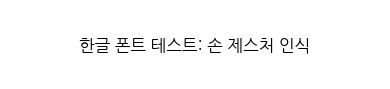

한글 폰트 설정 완료


In [2]:
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트: 손 제스처 인식', ha='center', va='center', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print('한글 폰트 설정 완료')

seed 고정

In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f'SEED 고정 완료: {SEED}')

SEED 고정 완료: 42


3. API키 업로드

In [4]:
from google.colab import files
import os
import shutil

uploaded = files.upload()  # kaggle.json 선택

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

uploaded_files = list(uploaded.keys())
if len(uploaded_files) == 0:
    raise FileNotFoundError('업로드된 파일이 없습니다. kaggle.json 파일을 업로드하세요.')

uploaded_kaggle_file = uploaded_files[0]
target_path = os.path.expanduser('~/.kaggle/kaggle.json')

shutil.copy(uploaded_kaggle_file, target_path)
os.chmod(target_path, 0o600)

print(f'Kaggle 인증 완료! 업로드 파일: {uploaded_kaggle_file}')

Saving kaggle.json to kaggle.json
Kaggle 인증 완료! 업로드 파일: kaggle.json


4. 데이터셋 다운로드

In [5]:
!kaggle datasets download -d gti-upm/leapgestrecog -p /content/gesture --unzip

import os

BASE_PATH = '/content/gesture/leapGestRecog'
subjects = sorted(os.listdir(BASE_PATH))
print(f'피험자 수: {len(subjects)}명 -> {subjects}')

classes = sorted(os.listdir(os.path.join(BASE_PATH, subjects[0])))
print(f'제스처 클래스 ({len(classes)}개): {classes}')

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:14<00:00, 159MB/s]

피험자 수: 10명 -> ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
제스처 클래스 (10개): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


5. 데이터 샘플 시각화

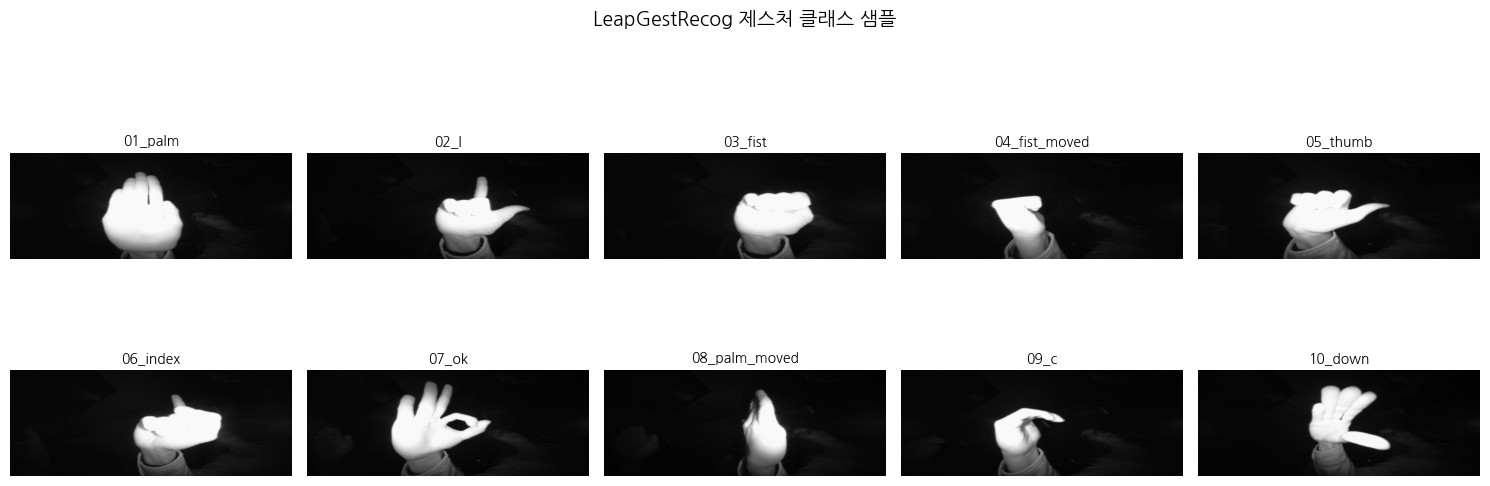

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

BASE_PATH = '/content/gesture/leapGestRecog'
subjects = sorted(os.listdir(BASE_PATH))
subject_path = os.path.join(BASE_PATH, subjects[0])
classes = sorted(os.listdir(subject_path))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(subject_path, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle('LeapGestRecog 제스처 클래스 샘플', fontsize=14)
plt.tight_layout()
plt.show()

6. 클래스 분포 확인

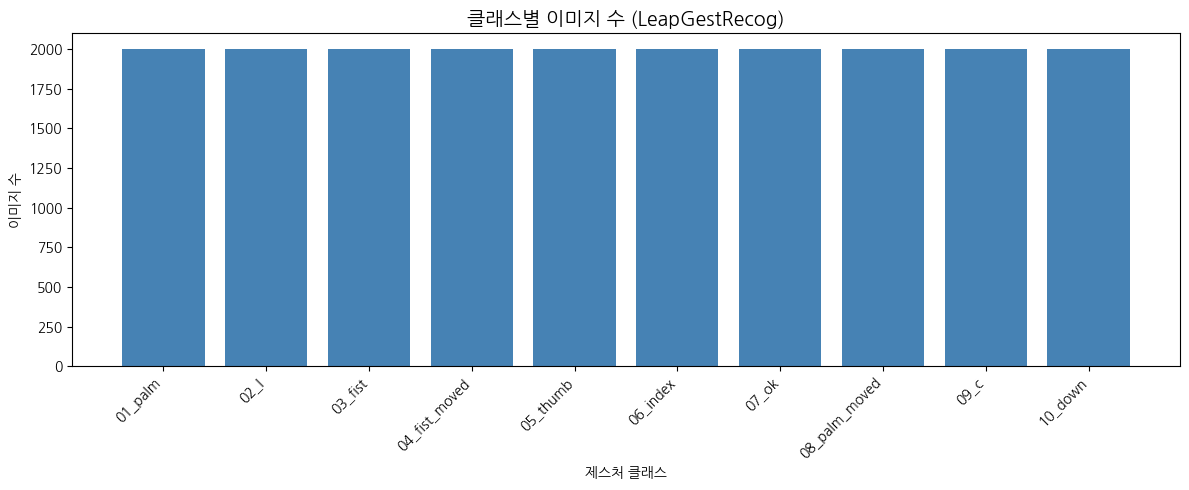

총 이미지 수: 20,000장
클래스 수: 10개
클래스 균형: 최소 2,000 / 최대 2,000


In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict
import os

BASE_PATH = '/content/gesture/leapGestRecog'
class_counts = defaultdict(int)

for subject in os.listdir(BASE_PATH):
    subject_path = os.path.join(BASE_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for cls in os.listdir(subject_path):
        cls_path = os.path.join(subject_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] += len(os.listdir(cls_path))

sorted_classes = sorted(class_counts.keys())
sorted_counts  = [class_counts[c] for c in sorted_classes]

plt.figure(figsize=(12, 5))
plt.bar(sorted_classes, sorted_counts, color='steelblue')
plt.title('클래스별 이미지 수 (LeapGestRecog)', fontsize=14)
plt.xlabel('제스처 클래스')
plt.ylabel('이미지 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'총 이미지 수: {sum(class_counts.values()):,}장')
print(f'클래스 수: {len(class_counts)}개')
print(f'클래스 균형: 최소 {min(sorted_counts):,} / 최대 {max(sorted_counts):,}')

7. Dataset 클래스 및 DataLoader

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

class LeapGestRecogDataset(Dataset):
    CLASSES = sorted(['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
                      '06_index','07_ok','08_palm_moved','09_c','10_down'])

    def __init__(self, base_path, subjects, transform=None):
        self.transform = transform
        self.classes   = self.CLASSES
        self.class_to_idx = {c: i for i, c in enumerate(self.CLASSES)}
        self.samples = []
        for subj in subjects:
            for cls in self.CLASSES:
                cls_path = os.path.join(base_path, subj, cls)
                if not os.path.isdir(cls_path): continue
                for fname in os.listdir(cls_path):
                    self.samples.append(
                        (os.path.join(cls_path, fname), self.class_to_idx[cls])
                    )

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

BASE_PATH = '/content/gesture/leapGestRecog'
train_subjects = ['00','01','02','03','04','05']
val_subjects   = ['06','07']
test_subjects  = ['08','09']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=15,
        translate=None      # ✅ translate 제거 → fist vs fist_moved 혼동 방지
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = LeapGestRecogDataset(BASE_PATH, train_subjects, train_transform)
val_dataset   = LeapGestRecogDataset(BASE_PATH, val_subjects,   eval_transform)
test_dataset  = LeapGestRecogDataset(BASE_PATH, test_subjects,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f'학습  피험자: {train_subjects} -> {len(train_dataset):,}장')
print(f'검증  피험자: {val_subjects}   -> {len(val_dataset):,}장')
print(f'테스트 피험자: {test_subjects}  -> {len(test_dataset):,}장')
print(f'클래스 수: {len(train_dataset.classes)}개')

사용 디바이스: cuda
학습  피험자: ['00', '01', '02', '03', '04', '05'] -> 12,000장
검증  피험자: ['06', '07']   -> 4,000장
테스트 피험자: ['08', '09']  -> 4,000장
클래스 수: 10개


8. 학습 및 평가 루프

In [9]:
import copy

# ============================================================
# ✅ 수정 1: Dropout 추가 — Classifier에 과적합 방지층 삽입
# ============================================================
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
num_classes = len(train_dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),                              # ✅ Dropout 0.4 추가
    nn.Linear(model.last_channel, num_classes)
)
model = model.to(device)

# ============================================================
# ✅ 수정 2: 2단계 학습 (Backbone Freezing → 전체 학습)
#   1단계: Backbone 고정, Classifier만 학습 (5 epoch)
#   2단계: 전체 레이어 학습 (LR 더 낮춰서)
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total * 100

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total * 100

criterion = nn.CrossEntropyLoss()
best_val_acc  = 0
best_weights  = None
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

# ── 1단계: Backbone 고정, Classifier만 학습 ──────────────────
print('=' * 65)
print('1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)')
print(f'{"Epoch":>6} {"TrainLoss":>10} {"TrainAcc":>10} {"ValLoss":>10} {"ValAcc":>10}')
print('-' * 65)

for param in model.features.parameters():  # Backbone 고정
    param.requires_grad = False

# ✅ 수정 3: Weight Decay 추가 → L2 정규화로 과적합 억제
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4       # ✅ Weight Decay
)

for epoch in range(1, 6):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    vl_loss, vl_acc = evaluate(val_loader)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    print(f'{epoch:>6} {tr_loss:>10.4f} {tr_acc:>9.2f}% {vl_loss:>10.4f} {vl_acc:>9.2f}%')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

# ── 2단계: 전체 레이어 해제, 낮은 LR로 Fine-tuning ───────────
print('\n' + '=' * 65)
print('2단계: 전체 레이어 학습 — Fine-tuning (patience=7)')
print(f'{"Epoch":>6} {"TrainLoss":>10} {"TrainAcc":>10} {"ValLoss":>10} {"ValAcc":>10} {"LR":>10}')
print('-' * 65)

for param in model.features.parameters():  # Backbone 해제
    param.requires_grad = True

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4       # ✅ Weight Decay 유지
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=3, min_lr=1e-6
)

patience, patience_counter = 7, 0

for epoch in range(6, 31):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    vl_loss, vl_acc = evaluate(val_loader)
    scheduler.step(vl_acc)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6} {tr_loss:>10.4f} {tr_acc:>9.2f}% {vl_loss:>10.4f} {vl_acc:>9.2f}% {lr_now:>10.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_weights, '/content/gesture_mobilenetv2_v3.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\n[Early Stopping] {patience}회 연속 개선 없음 → 종료')
            break

model.load_state_dict(best_weights)
print(f'\n=== 학습 완료 ===')
print(f'최고 검증 정확도: {best_val_acc:.2f}%')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 58.7MB/s]


1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc
-----------------------------------------------------------------
     1     1.3102     66.62%     0.9146     75.95%
     2     0.7369     81.02%     0.7365     76.95%
     3     0.5808     83.98%     0.6599     78.33%
     4     0.5177     85.16%     0.6222     77.83%
     5     0.4943     85.08%     0.5543     80.30%

2단계: 전체 레이어 학습 — Fine-tuning (patience=7)
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc         LR
-----------------------------------------------------------------
     6     0.0441     98.79%     0.1100     96.33%   1.00e-04
     7     0.0059     99.86%     0.0994     96.00%   1.00e-04
     8     0.0041     99.88%     0.1317     95.85%   1.00e-04
     9     0.0024     99.92%     0.1698     94.88%   1.00e-04
    10     0.0004    100.00%     0.1039     96.23%   3.00e-05
    11     0.0007     99.98%     0.0923     96.62%   3.00e-05
    12     0.0005     99.98%     0.1313  

9. 학습 곡선 시각화

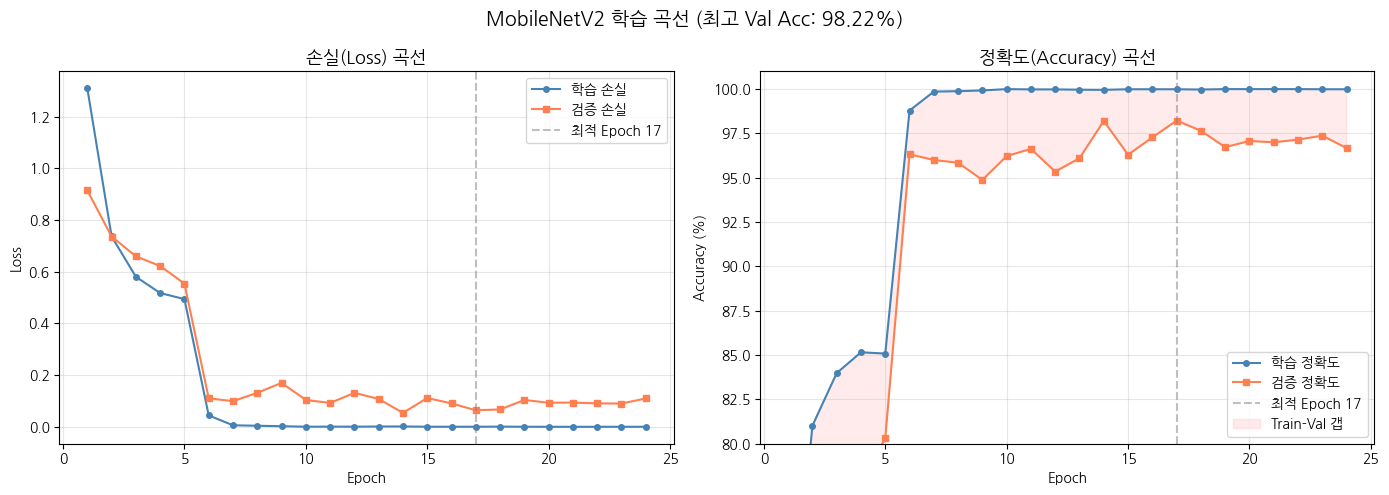

최종 Train-Val 정확도 갭: 3.32% (과적합 의심)


In [10]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
ax1.plot(x, history['train_loss'], label='학습 손실', color='steelblue', marker='o', markersize=4)
ax1.plot(x, history['val_loss'],   label='검증 손실', color='coral',     marker='s', markersize=4)

# ✅ 추가: 최적 에폭 표시
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')
ax1.set_title('손실(Loss) 곡선', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy 곡선
ax2.plot(x, history['train_acc'], label='학습 정확도', color='steelblue', marker='o', markersize=4)
ax2.plot(x, history['val_acc'],   label='검증 정확도', color='coral',     marker='s', markersize=4)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')

# ✅ 추가: Train-Val 갭 음영 표시 (과적합 가시화)
ax2.fill_between(x,
    history['train_acc'], history['val_acc'],
    alpha=0.08, color='red', label='Train-Val 갭')

ax2.set_title('정확도(Accuracy) 곡선', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([80, 101])
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'MobileNetV2 학습 곡선 (최고 Val Acc: {max(history["val_acc"]):.2f}%)', fontsize=14)
plt.tight_layout()
plt.show()

# ✅ 추가: Train-Val 갭 수치 출력
final_gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'최종 Train-Val 정확도 갭: {final_gap:.2f}% ', end='')
print('(과적합 의심)' if final_gap > 3 else '(양호)')

10. 테스트 셋 최종 평가

=== 테스트셋 최종 평가 (피험자 08, 09) ===
               precision    recall  f1-score   support

      01_palm       0.89      0.93      0.91       400
         02_l       0.97      0.93      0.95       400
      03_fist       0.97      0.54      0.69       400
04_fist_moved       0.72      0.94      0.82       400
     05_thumb       0.99      0.97      0.98       400
     06_index       0.98      0.97      0.98       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       0.93      1.00      0.97       400
         09_c       0.94      1.00      0.97       400
      10_down       0.96      1.00      0.98       400

     accuracy                           0.93      4000
    macro avg       0.94      0.93      0.92      4000
 weighted avg       0.94      0.93      0.92      4000



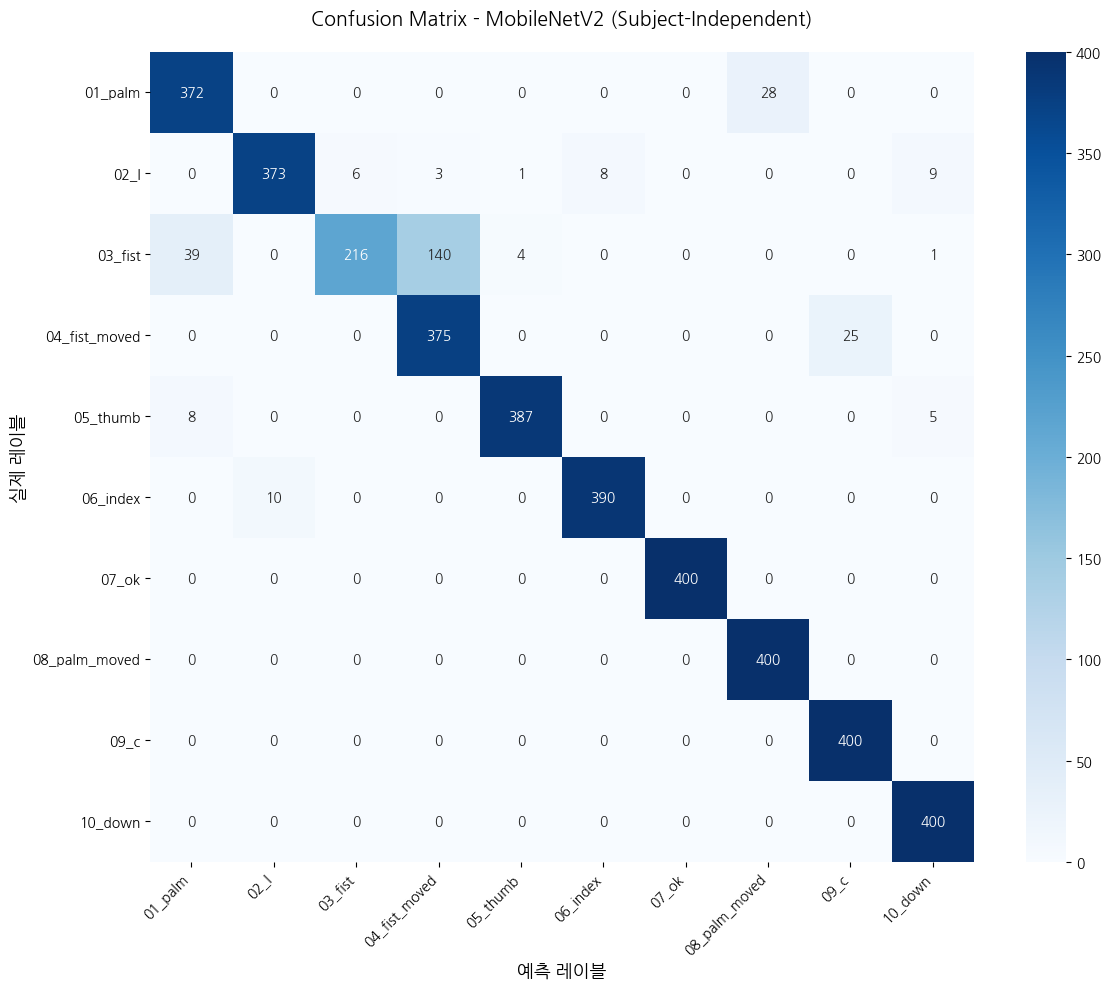

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = train_dataset.classes

print('=== 테스트셋 최종 평가 (피험자 08, 09) ===')
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('예측 레이블', fontsize=13, fontweight='bold')
plt.ylabel('실제 레이블', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix - MobileNetV2 (Subject-Independent)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

11. 예측 샘플 시각화

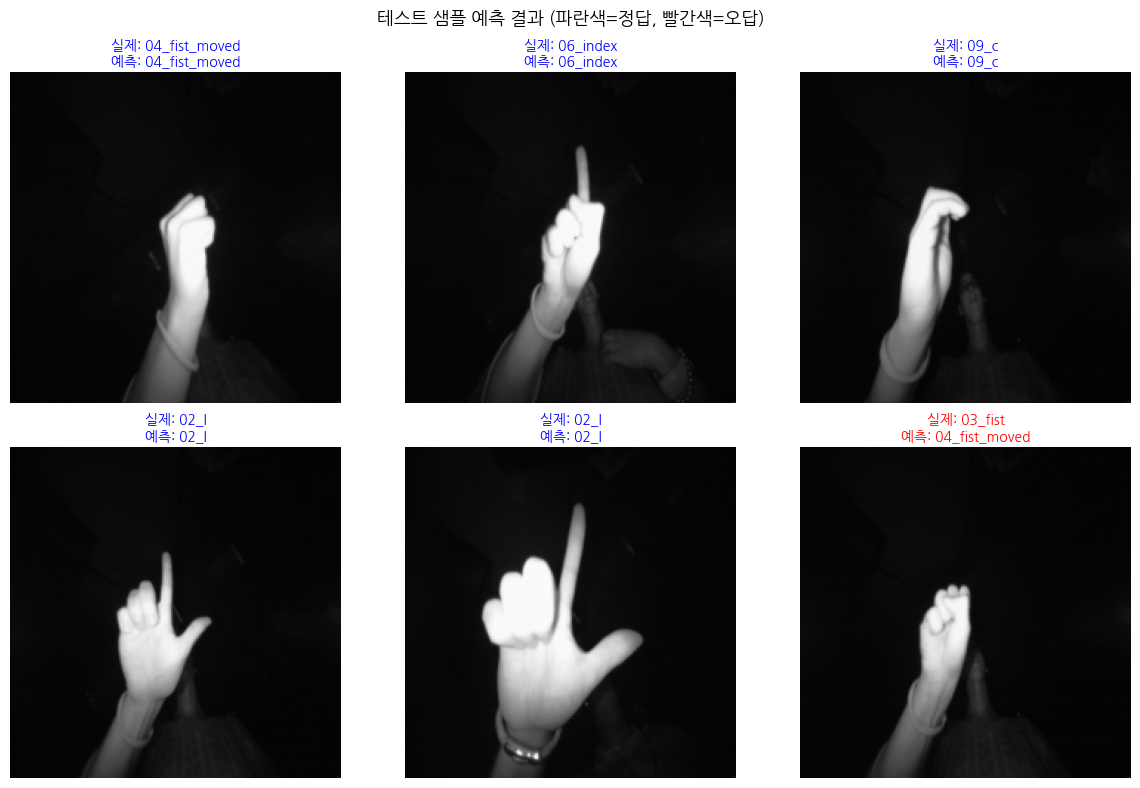

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt

model.eval()
class_names = train_dataset.classes
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

mean = np.array(IMAGENET_MEAN)
std = np.array(IMAGENET_STD)

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]
        img_input = image.unsqueeze(0).to(device)
        output    = model(img_input)
        _, predicted = torch.max(output, 1)

        # ✅ 올바른 역정규화
        img_display = image.permute(1, 2, 0).numpy()
        img_display = (img_display * std) + mean
        img_display = np.clip(img_display, 0, 1)

        true_label = class_names[label]
        pred_label = class_names[predicted.item()]
        color = 'blue' if true_label == pred_label else 'red'

        axes[i].imshow(img_display)
        axes[i].set_title(f'실제: {true_label}\n예측: {pred_label}', color=color, fontsize=10)
        axes[i].axis('off')

plt.suptitle('테스트 샘플 예측 결과 (파란색=정답, 빨간색=오답)', fontsize=13)
plt.tight_layout()
plt.show()

12. Gradio 데모

In [13]:
import gradio as gr
from PIL import Image as PILImage
import random
import numpy as np

def predict_gesture(input_image):
    if input_image is None:
        return {}
    if not isinstance(input_image, PILImage.Image):
        input_image = PILImage.fromarray(input_image)

    img_tensor = eval_transform(input_image.convert('RGB'))
    img_tensor = img_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()

    return {train_dataset.classes[i]: float(probs[i]) for i in range(len(train_dataset.classes))}

def get_random_test_sample():
    idx = random.randint(0, len(test_dataset) - 1)
    image_tensor, label = test_dataset[idx]

    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    img_display = image_tensor.permute(1, 2, 0).numpy()
    img_display = (img_display * std) + mean
    img_display = np.clip(img_display, 0, 1)
    img_display = (img_display * 255).astype(np.uint8)

    true_label = train_dataset.classes[label]
    return PILImage.fromarray(img_display), true_label

def predict_random_sample():
    sample_img, true_label = get_random_test_sample()
    pred_result = predict_gesture(sample_img)

    pred_label = max(pred_result, key=pred_result.get)
    correct_text = '정답' if pred_label == true_label else '오답'

    info_text = f'실제 라벨: {true_label}\n예측 라벨: {pred_label}\n판정: {correct_text}'
    return sample_img, pred_result, info_text

gesture_list = ', '.join(train_dataset.classes)
desc_text = f'LeapGestRecog 데이터셋 학습 (피험자 독립 분리)\n인식 가능 제스처: {gesture_list}'

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 손 제스처 인식 데모 - MobileNetV2')
    gr.Markdown(desc_text)

    with gr.Tab('직접 업로드 / 웹캠 예측'):
        input_image = gr.Image(label='손 사진 업로드 또는 웹캠 촬영', sources=['upload', 'webcam'], type='pil')
        output_label = gr.Label(num_top_classes=3, label='예측 결과 (상위 3개)')
        predict_btn = gr.Button('예측하기')
        predict_btn.click(fn=predict_gesture, inputs=input_image, outputs=output_label)

    with gr.Tab('랜덤 테스트 이미지 예측'):
        random_image = gr.Image(label='랜덤 테스트 이미지', type='pil')
        random_output = gr.Label(num_top_classes=3, label='예측 결과 (상위 3개)')
        random_info = gr.Textbox(label='정답 여부', lines=3)
        random_btn = gr.Button('랜덤 이미지 불러와 예측하기')
        random_btn.click(fn=predict_random_sample, inputs=None, outputs=[random_image, random_output, random_info])

demo.launch(share=True)

/tmp/ipykernel_584/3486990155.py:50: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cdc4407529624c2957.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
